<a href="https://colab.research.google.com/github/darjiavani/college-website/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv ('/content/emissions_reduction_data.csv')
print(data.head)

<bound method NDFrame.head of       energy_efficiency  renewable_ratio  technology_cost  emission_reduction
0             68.727006         0.373641      7569.984799                   0
1             97.535715         0.332912      2660.607960                   0
2             86.599697         0.176154      4119.757249                   0
3             79.932924         0.607267      6969.525732                   1
4             57.800932         0.476624      5338.804101                   0
...                 ...              ...              ...                 ...
9995          92.882799         0.877039      9570.479053                   0
9996          94.875442         0.046814      7730.417901                   0
9997          97.335396         0.303698      1175.102765                   0
9998          69.874400         0.443320      4609.043582                   0
9999          60.857020         0.172265      3316.581812                   0

[10000 rows x 4 columns]>


In [ ]:
data.shape

(10000, 4)

In [ ]:
X=data[['energy_efficiency','renewable_ratio','technology_cost']]
y=data['emission_reduction']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
k = 5
model =KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print('ACCURACY:', accuracy)

ACCURACY: 0.838


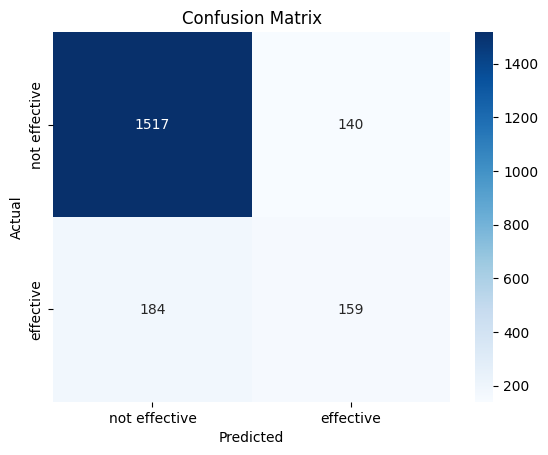

In [ ]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

conf_matrix = sk_confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
       xticklabels=['not effective', 'effective'],
       yticklabels=['not effective', 'effective'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred, target_names=['not effective', 'effective']))

               precision    recall  f1-score   support

not effective       0.89      0.92      0.90      1657
    effective       0.53      0.46      0.50       343

     accuracy                           0.84      2000
    macro avg       0.71      0.69      0.70      2000
 weighted avg       0.83      0.84      0.83      2000

